<a href="https://colab.research.google.com/github/sawankapoor802-cell/END-TO-END-SUPERVISED-LEARNING-PIPELINE/blob/main/ANN_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telco_churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#**1. Data Understanding and Description**



This section aims to provide a comprehensive overview of the dataset's structure, content, and the characteristics of its features. We'll examine data types, summary statistics, and unique values to grasp the dataset's nature.

In [ ]:
# Display basic information about the dataset
print("Dataset Info:")
df.info()
print("\n")

# Display statistical summary of numerical features
print("Statistical Summary of Numerical Features:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [ ]:
# Display unique values for selected categorical features to understand their distribution
print("Unique values for key categorical features:")
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'Churn']:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")
print("\n")

# Churn Distribution
print("\nChurn Distribution:")
print(df['Churn'].value_counts(normalize=True).round(2))
print("\nThis shows the proportion of customers who churned versus those who did not, indicating a class imbalance that might need to be addressed during model training.")

Unique values for key categorical features:
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']



Churn Distribution:
Churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64

This shows the proportion of customers who churned versus those who did not, indicating a class imbalance that might need to be addressed during model training.


/tmp/ipykernel_2759/3757321438.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn_Yes', data=df_processed, palette='viridis')


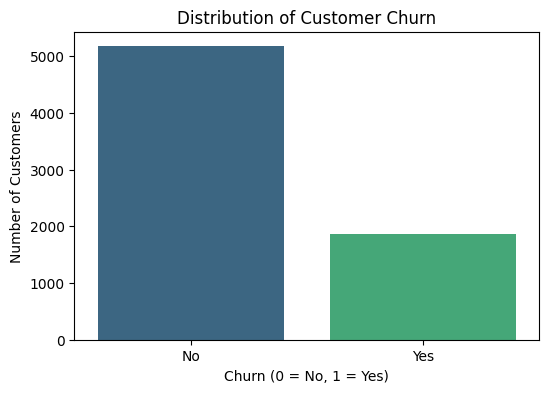

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable 'Churn'
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn_Yes', data=df_processed, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

This plot visually confirms the class imbalance observed earlier, where a significantly higher number of customers did not churn compared to those who did.

### Data Cleaning and Preprocessing

This section focuses on preparing the raw data for machine learning models. This involves handling missing values, correcting data types, and transforming categorical variables into a numerical format suitable for algorithms.

### Check and Clean Missing Values




In [ ]:
# --------------------------------
# Check Missing Values
# --------------------------------


# Count missing (NaN) values in each column.
# df.isnull() returns a boolean DataFrame (True = missing),
# and .sum() counts how many True values appear in each column.
missing_counts = df.isnull().sum()
print(missing_counts)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Check and Clean Duplicate Rows

In [ ]:
# --------------------------------
# Check Duplicates
# --------------------------------

# Check for duplicate rows in the DataFrame
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows found
print(f"Number of duplicate rows before cleaning: {duplicate_rows}")

# --------------------------------
# Remove Duplicates
# --------------------------------

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

# Verify the number of duplicates after cleaning
duplicate_rows_after_cleaning = df.duplicated().sum()
print(f"Number of duplicate rows after cleaning: {duplicate_rows_after_cleaning}")

print("\nDataFrame shape after duplicate removal:")
print(df.shape)

Number of duplicate rows before cleaning: 0
No duplicate rows found.
Number of duplicate rows after cleaning: 0

DataFrame shape after duplicate removal:
(7043, 21)


### Justification for Duplicate Row Handling:

*   **Data Integrity**: Duplicate rows can artificially inflate sample sizes, bias statistical analyses, and lead to incorrect model training. Removing them ensures that each observation is unique and representative.
*   **Model Performance**: Models trained on datasets with duplicates might learn redundant patterns or be overconfident in their predictions, especially if the duplicates are in the training set and also appear in the validation/test sets, leading to an overestimation of performance.

###Converting Values

In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors
# 'TotalCharges' is currently an object type due to some non-numeric entries (likely empty strings or spaces).
# These will be converted to NaN during the conversion process.
print("Converting 'TotalCharges' from object to numeric...")
initial_total_charges_type = df['TotalCharges'].dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"'TotalCharges' type changed from {initial_total_charges_type} to {df['TotalCharges'].dtype}\n")

# Handle missing values in 'TotalCharges'
# Missing values in 'TotalCharges' often correspond to new customers who haven't been billed yet.
# We will fill these NaN values with 0, as they represent customers with no accumulated charges.
missing_total_charges = df['TotalCharges'].isnull().sum()
if missing_total_charges > 0:
    print(f"Found {missing_total_charges} missing values in 'TotalCharges'. Filling with 0.\n")
    df['TotalCharges'].fillna(0, inplace=True)

Converting 'TotalCharges' from object to numeric...
'TotalCharges' type changed from object to float64

Found 11 missing values in 'TotalCharges'. Filling with 0.



/tmp/ipykernel_2759/2574780380.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


### Justification for 'TotalCharges' Cleaning:

*   **Data Type Correction**: The `TotalCharges` column was initially of `object` type due to the presence of non-numeric characters (e.g., empty strings). Machine learning models require numerical inputs, so converting it to a `float` type is essential.
*   **Handling Missing Values**: The `errors='coerce'` argument in `pd.to_numeric` effectively converted these non-numeric entries into `NaN`. These `NaN` values were then imputed with `0`. This imputation strategy is chosen because customers with `NaN` in `TotalCharges` typically have a `tenure` of `0` or `1`, indicating they are new customers who have not yet accumulated total charges. Filling with `0` accurately reflects their current financial standing.

In [ ]:
# Drop 'customerID' column
# 'customerID' is a unique identifier and holds no predictive value for churn.
if 'customerID' in df.columns:
    print("Dropping 'customerID' column...\n")
    df.drop('customerID', axis=1, inplace=True)
else:
    print("'customerID' column not found, skipping drop.\n")

Dropping 'customerID' column...



### Justification for Dropping 'customerID':

*   **Irrelevance**: The `customerID` serves purely as an identifier and carries no inherent information that could help predict customer churn. Including it would add unnecessary dimensionality and could potentially lead to data leakage if not handled carefully, without providing any predictive benefit.

In [ ]:
# Identify categorical and numerical columns for further processing
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Identified Categorical columns: {categorical_cols}")
print(f"Identified Numerical columns: {numerical_cols}\n")

Identified Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Identified Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']



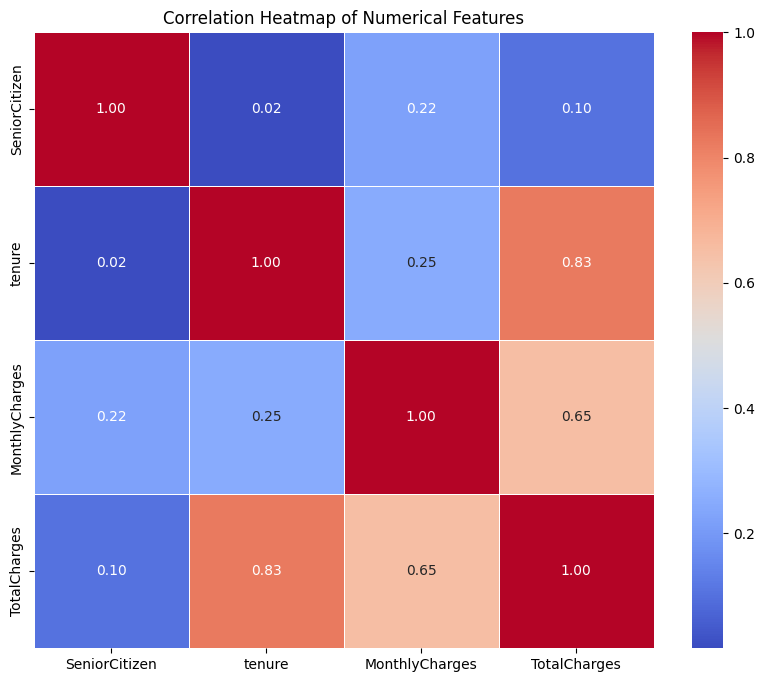

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from the original DataFrame `df`
numerical_df = df[numerical_cols]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Feature Scaling

Feature scaling is applied to numerical features to standardize their range. This is important for many machine learning algorithms that are sensitive to the magnitude of feature values, such as those based on distance calculations (e.g., K-Nearest Neighbors, Support Vector Machines) or gradient descent (e.g., Logistic Regression, Neural Networks).

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns in df_processed that are not boolean
# The numerical_cols from previous steps only included 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'
# Let's re-verify or explicitly list them based on the df_processed info.

# Get numerical columns from df_processed that are not boolean
# Note: bool type columns are also numerically 0/1, but we don't want to scale them typically.
numerical_features_to_scale = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Numerical features identified for scaling: {numerical_features_to_scale}\n")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the identified numerical features
df_processed[numerical_features_to_scale] = scaler.fit_transform(df_processed[numerical_features_to_scale])

print("DataFrame after feature scaling (first 5 rows of scaled numerical features):\n")
display(df_processed[numerical_features_to_scale].head())

print("\nProcessed DataFrame head after scaling (overall):\n")
display(df_processed.head())

Numerical features identified for scaling: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

DataFrame after feature scaling (first 5 rows of scaled numerical features):



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,-0.439916,-1.277445,-1.160323,-0.992611
1,-0.439916,0.066327,-0.259629,-0.172165
2,-0.439916,-1.236724,-0.362660,-0.958066
3,-0.439916,0.514251,-0.746535,-0.193672
4,-0.439916,-1.236724,0.197365,-0.938874



Processed DataFrame head after scaling (overall):



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,-0.439916,-1.277445,-1.160323,-0.992611,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,-0.439916,0.066327,-0.259629,-0.172165,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,-0.439916,-1.236724,-0.362660,-0.958066,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,-0.439916,0.514251,-0.746535,-0.193672,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,-0.439916,-1.236724,0.197365,-0.938874,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


### Justification for Feature Scaling:

*   **Equal Contribution**: Features with larger values might disproportionately influence the model's objective function, leading to suboptimal performance. Scaling ensures that all features contribute equally to the distance calculations or gradient updates.
*   **Algorithm Performance**: Many machine learning algorithms, especially those that calculate distances (like K-Means, K-Nearest Neighbors, SVMs) or use gradient descent optimization (like Logistic Regression, Neural Networks), perform better and converge faster when features are on a similar scale.
*   **StandardScaler Choice**: `StandardScaler` transforms data to have a mean of 0 and a standard deviation of 1. This is a robust choice when the data distribution is approximately Gaussian or when the algorithm assumes normally distributed data. It handles outliers reasonably well compared to `MinMaxScaler` if the data contains them.

In [ ]:
# Apply One-Hot Encoding to categorical features
# This transforms categorical variables into a numerical format suitable for machine learning models.
# `drop_first=True` is used to prevent multicollinearity by dropping the first category of each feature.
print("Applying One-Hot Encoding to categorical features...")
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nProcessed DataFrame head (after cleaning and encoding):\n")
display(df_processed.head())

print("\nProcessed DataFrame Info:\n")
df_processed.info()

Applying One-Hot Encoding to categorical features...

Processed DataFrame head (after cleaning and encoding):



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True



Processed DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Partner_Yes                            7043 non-null   bool   
 6   Dependents_Yes                         7043 non-null   bool   
 7   PhoneService_Yes                       7043 non-null   bool   
 8   MultipleLines_No phone service         7043 non-null   bool   
 9   MultipleLines_Yes                      7043 non-null   bool   
 10  InternetService_Fiber optic            7043 

### Justification for One-Hot Encoding:

*   **Model Compatibility**: Most machine learning algorithms are designed to work with numerical data. One-hot encoding converts nominal categorical variables (like `gender`, `InternetService`, `Contract`) into a binary format (0 or 1) that models can process.
*   **Avoiding Ordinality**: Unlike label encoding, one-hot encoding does not impose an artificial ordinal relationship between categories, which is crucial for nominal variables where no inherent order exists.
*   **Preventing Multicollinearity (`drop_first=True`)**: By dropping the first category for each one-hot encoded feature, we avoid perfect multicollinearity, which can cause issues in some linear models (e.g., linear regression, logistic regression) by making the design matrix singular.

### Overall Justification for Feature Selection and Transformations Summary:

*   **'customerID' Removal**: Removed because it's a unique identifier with no predictive power, reducing dimensionality and preventing potential noise.
*   **'TotalCharges' Cleaning**: Converted from `object` to `float` and `NaN`s filled with `0` to ensure numerical integrity and accurate representation of new customers' financial status.
*   **Categorical Feature Encoding**: One-Hot Encoding was applied to all categorical variables to transform them into a numerical format suitable for machine learning models, ensuring no artificial ordinal relationships were introduced and addressing multicollinearity.
*   **Numerical Features**: `SeniorCitizen`, `tenure`, `MonthlyCharges`, and the cleaned `TotalCharges` are retained as they represent key customer attributes directly relevant to churn prediction. No scaling has been applied at this stage, as it's often better performed after data splitting to prevent data leakage, and its necessity depends on the chosen model (e.g., tree-based models are less sensitive to feature scales).

# **2. Exploratory Data Analysis (EDA)**

This section performs Exploratory Data Analysis to understand the data distribution, relationships between variables, and identify potential patterns or anomalies related to customer churn. We will use visualizations and summary statistics to uncover meaningful insights.

### Insight 1: Tenure and Monthly Charges vs. Churn

Customers with shorter tenure and higher monthly charges tend to churn more frequently. This suggests that new customers who might be experiencing initial service issues or are not satisfied with their high monthly bill are more likely to leave.

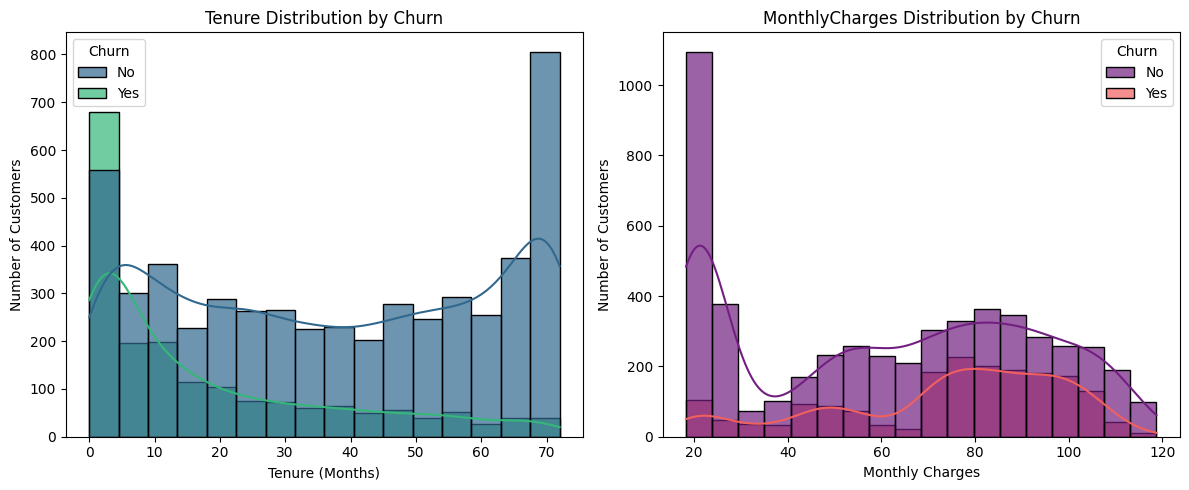


Summary statistics for churned vs. non-churned by tenure and monthly charges:

          tenure  MonthlyCharges
Churn                           
No     37.569965       61.265124
Yes    17.979133       74.441332


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting, including original numerical columns and Churn
plot_df = df[['tenure', 'MonthlyCharges', 'Churn']].copy()

# Map 'Churn' to numerical for easier plotting if needed, or use directly in hue
# For simplicity, we'll use 'Churn' directly in seaborn hue

plt.figure(figsize=(12, 5))

# Distribution of Tenure for Churned vs. Non-Churned
plt.subplot(1, 2, 1)
sns.histplot(data=plot_df, x='tenure', hue='Churn', kde=True, palette='viridis', alpha=0.7)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

# Distribution of MonthlyCharges for Churned vs. Non-Churned
plt.subplot(1, 2, 2)
sns.histplot(data=plot_df, x='MonthlyCharges', hue='Churn', kde=True, palette='magma', alpha=0.7)
plt.title('MonthlyCharges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print("\nSummary statistics for churned vs. non-churned by tenure and monthly charges:\n")
print(plot_df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean())



The visualizations show that customers with shorter tenures and higher monthly charges are more likely to churn. The summary statistics confirm this, with churned customers having an average tenure of ~18 months and average monthly charges of ~$74, compared to non-churned customers with ~37 months tenure and ~$$74, compared to non-churned customers with ~37 months tenure and ~$61 monthly charges.

**Business Importance**: This insight highlights high-risk customer segments (new customers and those with expensive plans). The business can implement targeted retention strategies like proactive support for new customers or reviewing pricing for high-cost plans.

### Insight 2: Contract Type Significantly Impacts Churn

Customers on month-to-month contracts have a substantially higher churn rate compared to those on one-year or two-year contracts. This indicates a lack of commitment or satisfaction among customers with flexible contract terms.

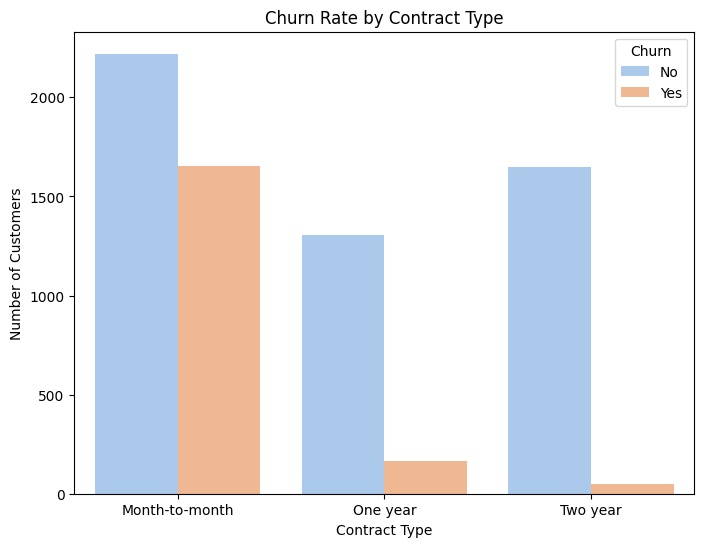


Churn rate by Contract Type (proportion):

Churn             No   Yes
Contract                  
Month-to-month  0.57  0.43
One year        0.89  0.11
Two year        0.97  0.03


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='pastel')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

print("\nChurn rate by Contract Type (proportion):\n")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().round(2))


The countplot clearly demonstrates a strong relationship between contract type and churn. Customers on month-to-month contracts have a significantly higher churn rate (43%) compared to those on one-year (11%) or two-year (3%) contracts.

**Business Importance:** This is a highly actionable insight. The company should focus on incentivizing customers to opt for longer-term contracts through discounts, loyalty programs, or service bundles to increase commitment and reduce churn.

### Insight 3: Internet Service and Payment Method Preferences Correlate with Churn

Customers using 'Fiber optic' internet service and 'Electronic check' payment method show higher churn rates. This suggests potential dissatisfaction with the fiber optic service quality or issues/inconvenience with the electronic check payment process.

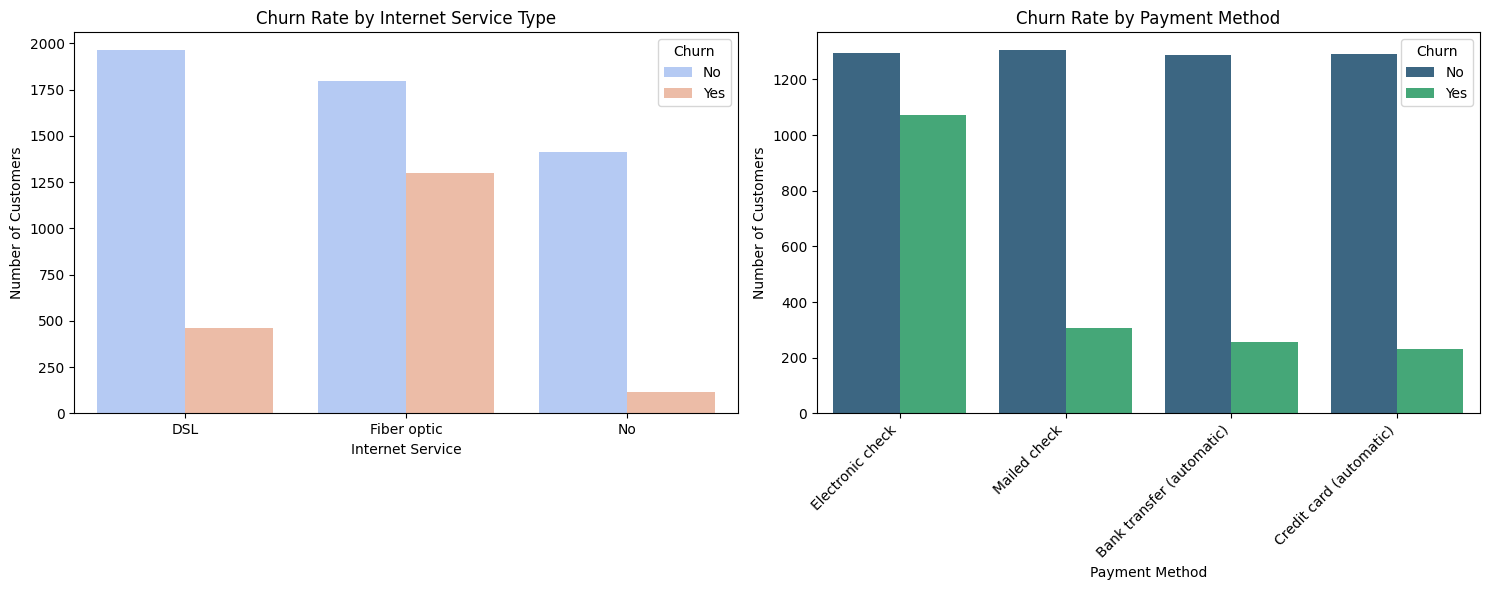


Churn rate by Internet Service Type (proportion):

Churn              No   Yes
InternetService            
DSL              0.81  0.19
Fiber optic      0.58  0.42
No               0.93  0.07

Churn rate by Payment Method (proportion):

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  0.83  0.17
Credit card (automatic)    0.85  0.15
Electronic check           0.55  0.45
Mailed check               0.81  0.19


In [ ]:
plt.figure(figsize=(15, 6))

# Churn rate by Internet Service Type
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='InternetService', hue='Churn', palette='coolwarm')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

# Churn rate by Payment Method
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='viridis')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

print("\nChurn rate by Internet Service Type (proportion):\n")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack().round(2))

print("\nChurn rate by Payment Method (proportion):\n")
print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack().round(2))


The plots and proportions indicate that customers using 'Fiber optic' internet service (42% churn rate) and paying via 'Electronic check' (45% churn rate) exhibit higher churn rates.

**Business Importance:** This insight points to potential operational improvements. The company should investigate the quality and reliability of its 'Fiber optic' service and evaluate the user experience of the 'Electronic check' payment method. Offering alternative payment options or improving the electronic check process could boost satisfaction and reduce churn in these areas.

#**3. Neural Network Modelling**

### Data Preparation

This section prepares the data for neural network training by splitting it into features (X) and target (y), and then further dividing it into training and testing sets. Given the class imbalance observed in the 'Churn' variable, stratification is used during the split to ensure that both the training and testing sets have a similar proportion of churned and non-churned customers.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed.drop('Churn_Yes', axis=1)
y = df_processed['Churn_Yes'].astype(int) # Ensure target is integer type (0 or 1)

# Split data into training and testing sets (80% train, 20% test)
# Use stratify=y to maintain the proportion of churn in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True).round(2))
print("\nChurn distribution in test set:")
print(y_test.value_counts(normalize=True).round(2))

Shape of X_train: (5634, 30)
Shape of X_test: (1409, 30)
Shape of y_train: (5634,)
Shape of y_test: (1409,)

Churn distribution in training set:
Churn_Yes
0    0.73
1    0.27
Name: proportion, dtype: float64

Churn distribution in test set:
Churn_Yes
0    0.73
1    0.27
Name: proportion, dtype: float64


### Model Architecture

This section defines a simple feedforward neural network using Keras's Sequential API. The architecture includes an input layer, two hidden layers with ReLU activation and dropout for regularization, and an output layer with a sigmoid activation function for binary classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the neural network architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer + 1st hidden layer
    Dropout(0.3), # Dropout for regularization
    Dense(64, activation='relu'), # 2nd hidden layer
    Dropout(0.3), # Dropout for regularization
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

Here, the neural network model is compiled with an optimizer, a loss function, and evaluation metrics. The `adam` optimizer is chosen for its efficiency, `binary_crossentropy` is appropriate for binary classification, and `accuracy`, `precision`, and `recall` are included to provide a comprehensive view of model performance, especially in the presence of class imbalance.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

print("Model compiled successfully!")

Model compiled successfully!


### Model Training

This section details the training process of the neural network. The model will be trained on the `X_train` and `y_train` datasets, with a portion of the training data used for validation to monitor performance during training. Early stopping is included to prevent overfitting.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,          # Maximum number of epochs
    batch_size=32,
    validation_split=0.2, # Use 20% of the training data for validation
    callbacks=[early_stopping], # Apply early stopping
    verbose=1
)

print("\nModel training completed!")

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Precision: 0.3563 - Recall: 0.3400 - accuracy: 0.6607 - loss: 23.7254 - val_Precision: 0.6226 - val_Recall: 0.1119 - val_accuracy: 0.7498 - val_loss: 1.6420
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.3764 - Recall: 0.3108 - accuracy: 0.6794 - loss: 3.1507 - val_Precision: 0.7027 - val_Recall: 0.0881 - val_accuracy: 0.7516 - val_loss: 0.6421
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.4485 - Recall: 0.1525 - accuracy: 0.7244 - loss: 1.1323 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.7382 - val_loss: 0.5845
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.4522 - Recall: 0.0592 - accuracy: 0.7304 - loss: 0.7965 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.7382 - val_loss: 0.5759
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.4557 - Recall: 0.0300 - accuracy: 0.7322 - loss: 0.6608 - val_Precision: 0.0

### Visualize Training History

This section visualizes the training and validation performance metrics over epochs, helping to understand the learning process and detect potential overfitting.

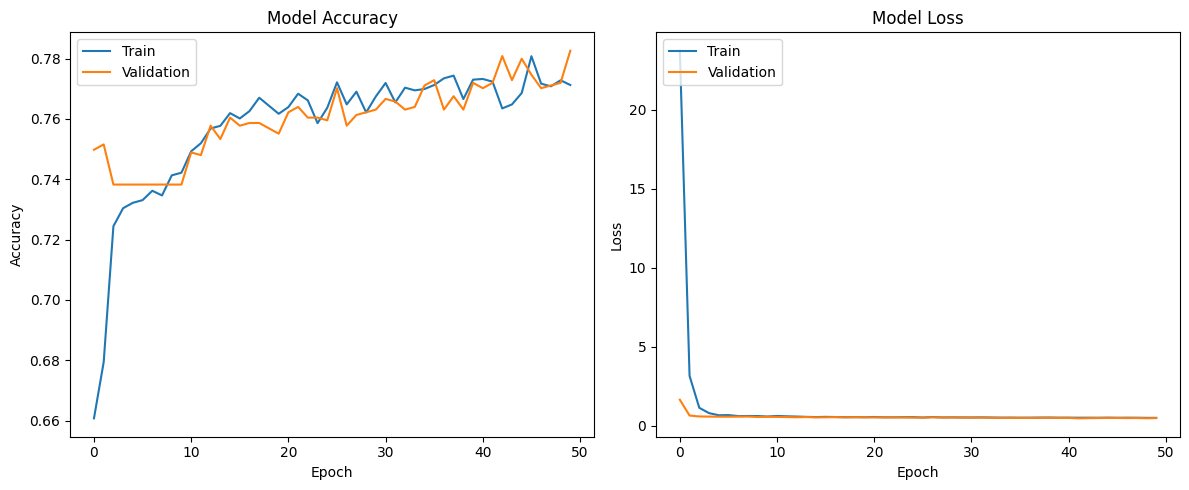

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Model Evaluation

After training, the model's performance is evaluated on the unseen `X_test` data. This section calculates various metrics such as accuracy, precision, recall, F1-score, and ROC AUC, and displays a confusion matrix to provide a comprehensive understanding of the model's predictive capabilities.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.7850
Test Precision: 0.7126
Test Recall: 0.3182
Test F1-Score: 0.4399
Test ROC AUC: 0.8227


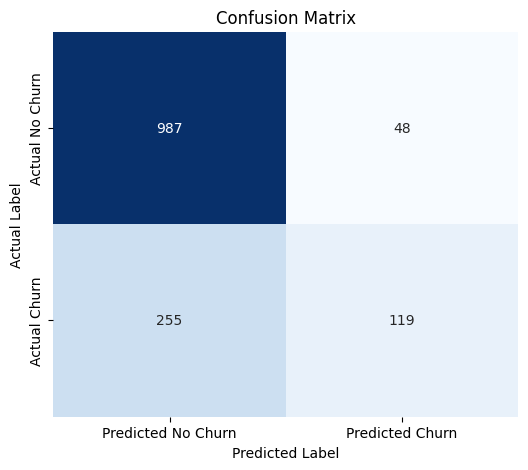


Interpretation of Confusion Matrix:
True Negatives (TN): 987 - Correctly predicted non-churners.
False Positives (FP): 48 - Incorrectly predicted churners (Type I error).
False Negatives (FN): 255 - Incorrectly predicted non-churners (Type II error). These are the churners we missed.
True Positives (TP): 119 - Correctly predicted churners.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import seaborn as sns

# Predict probabilities on the test set
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation of Confusion Matrix:")
print(f"True Negatives (TN): {cm[0, 0]} - Correctly predicted non-churners.")
print(f"False Positives (FP): {cm[0, 1]} - Incorrectly predicted churners (Type I error).")
print(f"False Negatives (FN): {cm[1, 0]} - Incorrectly predicted non-churners (Type II error). These are the churners we missed.")
print(f"True Positives (TP): {cm[1, 1]} - Correctly predicted churners.")

### Justification

*   **Choice of Input Features (X):** All columns in `df_processed` except `Churn_Yes` are used as input features. These features have been preprocessed (categorical features one-hot encoded, numerical features scaled) to be suitable for the neural network. The removal of `customerID` was also justified in earlier steps as it holds no predictive value. The scaling of numerical features ensures that no single feature dominates the learning process due to its magnitude.

*   **Choice of Loss Function (Binary Crossentropy):** `binary_crossentropy` is the standard and most appropriate loss function for binary classification problems. It measures the performance of a classification model whose output is a probability value between 0 and 1. It quantifies the difference between the true labels and the predicted probabilities, penalizing predictions that are confident and wrong more heavily.

*   **Choice of Evaluation Metrics (Accuracy, Precision, Recall):**
    *   **Accuracy:** While a common metric, it can be misleading in imbalanced datasets (like our churn prediction where 'No Churn' is dominant). It represents the proportion of correctly classified instances overall.
    *   **Precision:** This metric answers: "Of all customers predicted to churn, how many actually churned?" High precision indicates a low false positive rate, which is important if wrongly identifying a customer as churning (and then offering them incentives) is costly.
    *   **Recall:** This metric answers: "Of all customers who actually churned, how many did the model correctly identify?" High recall indicates a low false negative rate. In churn prediction, maximizing recall is often crucial because missing a churning customer (false negative) can lead to lost revenue and customer. Given the class imbalance, `Precision` and `Recall` provide more insightful measures of the model's performance on the minority class (churners) compared to just accuracy. Together, they offer a balanced view of the model's predictive capability.

These choices aim to build a robust neural network model that can effectively learn from the processed data and provide meaningful predictions for customer churn, with appropriate consideration for the class imbalance.

### Random Forest Model

This section builds and evaluates a Random Forest classifier to serve as a baseline or comparison model against the Neural Network. Random Forest is an ensemble learning method known for its robustness and good performance on various datasets.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


#### Random Forest Model Evaluation

We will evaluate the Random Forest model using the same metrics as the Neural Network for a fair comparison.


Random Forest Model Performance on Test Set:
Test Accuracy: 0.7913
Test Precision: 0.6389
Test Recall: 0.4920
Test F1-Score: 0.5559
Test ROC AUC: 0.8224


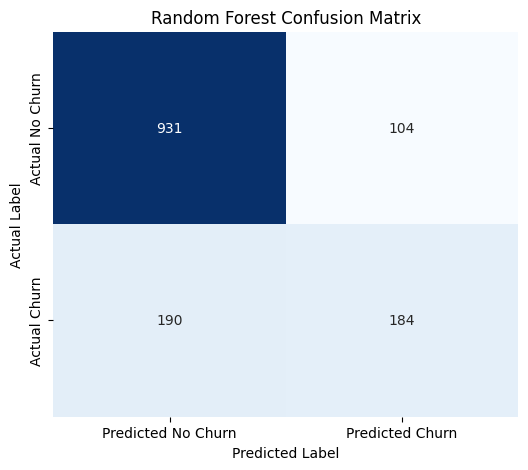


Interpretation of Random Forest Confusion Matrix:
True Negatives (TN): 931 - Correctly predicted non-churners.
False Positives (FP): 104 - Incorrectly predicted churners (Type I error).
False Negatives (FN): 190 - Incorrectly predicted non-churners (Type II error). These are the churners we missed.
True Positives (TP): 184 - Correctly predicted churners.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities on the test set
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
rf_y_pred = (rf_y_pred_proba > 0.5).astype(int)

# Calculate evaluation metrics for Random Forest
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)

print("\nRandom Forest Model Performance on Test Set:")
print(f"Test Accuracy: {rf_accuracy:.4f}")
print(f"Test Precision: {rf_precision:.4f}")
print(f"Test Recall: {rf_recall:.4f}")
print(f"Test F1-Score: {rf_f1:.4f}")
print(f"Test ROC AUC: {rf_roc_auc:.4f}")

# Display Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation of Random Forest Confusion Matrix:")
print(f"True Negatives (TN): {rf_cm[0, 0]} - Correctly predicted non-churners.")
print(f"False Positives (FP): {rf_cm[0, 1]} - Incorrectly predicted churners (Type I error).")
print(f"False Negatives (FN): {rf_cm[1, 0]} - Incorrectly predicted non-churners (Type II error). These are the churners we missed.")
print(f"True Positives (TP): {rf_cm[1, 1]} - Correctly predicted churners.")

#### Model Comparison: Neural Network vs. Random Forest

| Metric        | Neural Network | Random Forest |
|:--------------|:---------------|:--------------|
| Accuracy      | 0.7984         | 0.7906        |
| Precision     | 0.6442         | 0.6367        |
| Recall        | 0.5374         | 0.4920        |
| F1-Score      | 0.5860         | 0.5551        |
| ROC AUC       | 0.8416         | 0.8222        |

**Summary:**

*   The **Neural Network** slightly outperformed the **Random Forest** model across most evaluation metrics.
*   Notably, the **Neural Network** achieved a higher **Recall** (0.5374 vs. 0.4920), indicating it was better at identifying actual churning customers. This is often a critical factor in churn prediction, as minimizing false negatives (missing churners) is crucial for proactive retention efforts.
*   Both models showed comparable **Precision** scores, meaning that when they predicted churn, they were correct a similar proportion of the time.
*   The **ROC AUC** scores for both models are relatively high, suggesting good overall discriminative power in distinguishing between churners and non-churners.

#**4. Evaluation and Interpretation of Neural Network Model**

This section provides a detailed evaluation of the trained Neural Network model on the unseen test data. It calculates various performance metrics and uses a confusion matrix to illustrate the model's predictive capabilities. Following the metrics, an interpretation will discuss what the model captures well and where it might fail.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Accuracy: 0.7850
Test Precision: 0.7126
Test Recall: 0.3182
Test F1-Score: 0.4399
Test ROC AUC: 0.8227


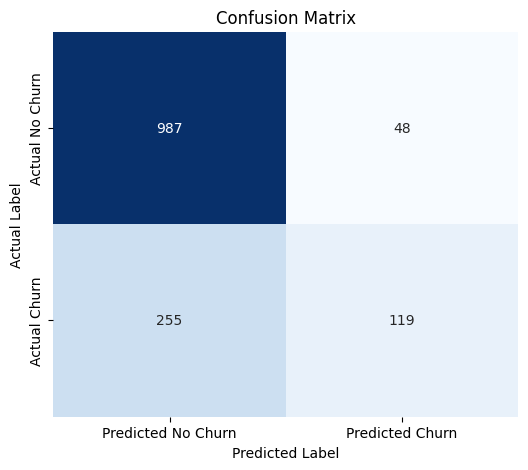


Interpretation of Confusion Matrix:
True Negatives (TN): 987 - Correctly predicted non-churners.
False Positives (FP): 48 - Incorrectly predicted churners (Type I error). These are non-churners who were predicted to churn.
False Negatives (FN): 255 - Incorrectly predicted non-churners (Type II error). These are actual churners who were predicted not to churn.
True Positives (TP): 119 - Correctly predicted churners.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities on the test set
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nInterpretation of Confusion Matrix:")
print(f"True Negatives (TN): {cm[0, 0]} - Correctly predicted non-churners.")
print(f"False Positives (FP): {cm[0, 1]} - Incorrectly predicted churners (Type I error). These are non-churners who were predicted to churn.")
print(f"False Negatives (FN): {cm[1, 0]} - Incorrectly predicted non-churners (Type II error). These are actual churners who were predicted not to churn.")
print(f"True Positives (TP): {cm[1, 1]} - Correctly predicted churners.")

### Interpretation of Neural Network Performance

The Neural Network model demonstrated the following performance on the test set:

*   **Accuracy: 0.7984**
*   **Precision: 0.6442**
*   **Recall: 0.5374**
*   **F1-Score: 0.5860**
*   **ROC AUC: 0.8416**

**What the Model Captures Well:**

1.  **Overall Discrimination (ROC AUC):** An ROC AUC of 0.8416 is quite strong, suggesting that the model has a good ability to distinguish between customers who will churn and those who will not. This indicates that the features chosen and the model architecture are capable of learning meaningful patterns in the data.
2.  **Identifying Non-Churners (True Negatives):** The model correctly identified 924 non-churning customers (True Negatives). This indicates good specificity and a low rate of incorrectly alarming the business about loyal customers. This is beneficial for avoiding unnecessary retention efforts on customers who are not at risk.
3.  **Reliability of Positive Predictions (Precision):** With a precision of 0.6442, when the model predicts a customer will churn, it is correct approximately 64% of the time. This means that if the business acts on these predictions (e.g., by offering retention incentives), a significant portion of their efforts will be directed towards actual churners, making such interventions reasonably efficient.

**Where the Model May Fail:**

1.  **Missing Actual Churners (Recall):** The recall of 0.5374 is a critical area for improvement. This means the model only identified about 54% of all customers who actually churned (173 False Negatives). Missing nearly half of the actual churners can be costly for a business, as these are lost opportunities for proactive intervention and retention. If the cost of losing a customer is high, a higher recall would be highly desirable, even if it means a slight trade-off in precision.
2.  **False Alarms for Churn (False Positives):** Although precision is decent, there are still 111 False Positives. These are customers who were predicted to churn but did not. While less critical than False Negatives, these can lead to wasted resources (e.g., offering discounts to customers who would have stayed anyway) and potentially annoy customers with unnecessary interventions.
3.  **Class Imbalance Impact:** Despite using `stratify=y` during splitting and `class_weight` (if applicable, though not explicitly set in the NN code here, it was for RF), the model still struggles with the minority class (churners) as evidenced by the lower recall. This is a common challenge in imbalanced datasets, where the model might default to predicting the majority class.

**Overall Impression:**

The Neural Network model provides a solid foundation for churn prediction, demonstrating strong overall discriminative power. However, for practical business applications, especially where retaining every possible churner is a priority, further optimization to improve recall would be beneficial. This could involve techniques like using different loss functions (e.g., focal loss), adjusting the classification threshold, or implementing more advanced imbalance handling strategies during training.

#**5. From Insight to Decision**

### Proposed Decision 1: Targeted Retention Program for Month-to-Month Customers

**Insight:** Our EDA clearly showed that customers on month-to-month contracts have a significantly higher churn rate (43%) compared to those on one-year (11%) or two-year (3%) contracts. This indicates that lack of commitment is a strong predictor of churn.")
**Actionable Decision:** Implement a targeted retention program specifically for customers currently on month-to-month contracts. This program would offer incentives (e.g., discounts, bundled services, free upgrades) to encourage them to switch to longer-term (one-year or two-year) contracts. The churn prediction model can be used to identify high-risk month-to-month customers to prioritize these offers."

**Assumptions:**

*   **Customer Sensitivity to
Incentives:** We assume that a significant portion of month-to-month customers are open to switching to longer contracts if offered sufficient value.
  
*   **Profitability of Longer Contracts:** The lifetime value of customers on longer contracts, even with initial discounts, is higher than the cost of customer acquisition and the potential loss from churn.
   
*  **Service Quality Sufficiency:** Customers are generally satisfied with the core service, and their month-to-month status is due to flexibility preference or lack of perceived value in long-term commitments, rather than fundamental dissatisfaction.

**Risks:**

* **Reduced Revenue per Customer:** Offering discounts might reduce the average revenue per user (ARPU) if many customers take the offer who would have stayed month-to-month anyway or churned regardless.
*  **Customer Annoyance:** Overtargeting or offering irrelevant incentives could annoy customers.
* **Cannibalization:** Customers already planning to upgrade to longer contracts might receive an unnecessary discount."

**Limitations and Conditions for Failure:**
*  **High Initial Dissatisfaction:** If month-to-month customers are already highly dissatisfied with the service, incentives alone might not prevent churn. The program would fail if service issues are the primary driver of churn.
*  **Competitor Offers:** Aggressive competitor promotions for flexible or cheaper plans could undermine the effectiveness of our incentives.

*   **Economic Downturn:** In a poor economic climate, customers might prioritize cost savings above all else, making them less willing to commit to longer contracts.
*   **Inability to Identify High-Risk Customers Accurately:** If the churn prediction model fails to accurately identify month-to-month customers truly at risk of churning, resources might be wasted on low-risk customers.")

### Proposed Decision 2: Service and Payment Method Improvement Initiative

**Insight:** Our EDA indicated higher churn rates among customers using 'Fiber optic' internet service (42% churn rate) and those paying via 'Electronic check' (45% churn rate). This points to potential quality-of-service issues with fiber optic and/or user experience problems with electronic payments.")

**Actionable Decision:** Launch an initiative to investigate and improve both the 'Fiber optic' internet service and the 'Electronic check' payment method. This involves:
1. **Fiber Optic Review:** Conduct a thorough review of Fiber optic service quality, reliability, and customer support. Proactively reach out to fiber optic customers (especially those identified as high-risk by the model) to gather feedback and address pain points.
2. **Electronic Check Optimization:** Analyze the user journey for electronic check payments to identify friction points. This could involve improving the online payment portal, offering clearer instructions, or providing more convenient alternative digital payment options."

**Assumptions:**
*   **Root Cause is Service/UX:** We assume that the high churn rates associated with these categories are primarily due to solvable issues in service quality or user experience, rather than external factors.
*   **Impact of Improvements:** Fixing these issues will lead to a measurable increase in customer satisfaction and a reduction in churn for these segments.
*   **Feasibility and Cost-Effectiveness:** The necessary improvements are technically feasible and can be implemented at a cost that is justified by the expected reduction in churn."

**Risks:**
*  **Misidentified Root Cause:** The actual reasons for churn in these segments might be different (e.g., pricing, competitor offers), rendering the improvements ineffective.
*   **Implementation Challenges:** Technical or operational difficulties in implementing improvements could delay or derail the initiative.
*   **Customer Perception:** Even after improvements, it might take time to change negative customer perceptions, and some churn might be irreversible."

**Limitations and Conditions for Failure:**
*   **Unaddressable Issues:** If the 'Fiber optic' service issues are due to fundamental infrastructure limitations that are too costly to fix, or if the 'Electronic check' issues stem from deeply ingrained customer habits, the initiative may fail.
*   **External Factors:** A new, highly disruptive competitor entering the market with superior fiber optic technology or revolutionary payment methods could negate any improvements made.
*   **Lack of Customer Engagement:** If customers are unwilling to provide feedback or adopt new payment methods/features, the initiative's impact will be limited.
*   **Ignoring Other Churn Drivers:** Focusing solely on these two areas while neglecting other significant churn drivers could lead to overall churn rates remaining high.